# Clasificacion de Malformacion de Arnold-Chiari Tipo I
## Notebook 04 — Evaluacion Externa

Evalua el modelo sobre `data/val_externo/` (101 casos Chiari
no vistos durante el entrenamiento) y `data/cropped/normal/` (30 normales).

In [1]:
import json, warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import cv2
from PIL import Image
from tqdm.auto import tqdm

import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import (roc_auc_score, f1_score, confusion_matrix,
                              roc_curve, classification_report)

warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')

BASE         = Path('.').resolve()
DIR_VAL_EXT  = BASE / 'data' / 'val_externo'
DIR_NORMAL   = BASE / 'data' / 'cropped' / 'normal'
DIR_MODELS   = BASE / 'models'
DIR_REPORTS  = BASE / 'reports'
DIR_FIGURES  = BASE / 'reports' / 'figures'
DIR_GRADCAM  = BASE / 'reports' / 'gradcam'
DIR_FIGURES.mkdir(parents=True, exist_ok=True)
DIR_GRADCAM.mkdir(parents=True, exist_ok=True)

IMG_SIZE    = (224, 224)
EXTENSIONES = {'.jpg', '.jpeg', '.png'}

def listar(carpeta):
    imgs = []
    for ext in EXTENSIONES:
        imgs += list(Path(carpeta).glob(f'*{ext}'))
        imgs += list(Path(carpeta).glob(f'*{ext.upper()}'))
    return sorted(set(imgs))

def cargar_imagen(ruta):
    arr = np.array(Image.open(ruta).convert('L'), dtype=np.uint8)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    arr = clahe.apply(arr)
    arr_f = np.array(
        Image.fromarray(arr).resize(IMG_SIZE, Image.LANCZOS), dtype=np.float32
    ) / 255.0
    return np.stack([arr_f, arr_f, arr_f], axis=-1)

print('Configuracion lista')

c:\Users\Usuario\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Configuracion lista


## Parte A — Evaluacion externa

### A1. Carga del modelo

In [2]:
candidatos   = sorted(DIR_MODELS.glob('*.keras'))
kfold_models = [m for m in candidatos if 'kfold' in m.name]
ruta_modelo  = kfold_models[0] if kfold_models else candidatos[0]

print('Modelos disponibles:')
for m in candidatos:
    marca = '  <-- seleccionado' if m == ruta_modelo else ''
    print(f'  {m.name}{marca}')

modelo = keras.models.load_model(str(ruta_modelo))
ARCH   = ruta_modelo.stem.split('_')[1] if '_' in ruta_modelo.stem else 'Modelo'
print(f'\nModelo cargado: {ruta_modelo.name}')
print(f'Parametros    : {modelo.count_params():,}')

Modelos disponibles:
  chiari_DenseNet121_kfold - copia.keras  <-- seleccionado
  chiari_DenseNet121_kfold.keras
  chiari_EfficientNetB0_kfold - copia.keras
  chiari_EfficientNetB0_kfold.keras
  chiari_ResNet50V2_kfold - copia.keras
  chiari_ResNet50V2_kfold.keras

Modelo cargado: chiari_DenseNet121_kfold - copia.keras
Parametros    : 7,074,433


### A2. Dataset de evaluacion externa

In [3]:
chiari_ext = listar(DIR_VAL_EXT)
normal_ext = listar(DIR_NORMAL)

rutas_ext  = [str(p) for p in normal_ext] + [str(p) for p in chiari_ext]
labels_ext = [0]*len(normal_ext) + [1]*len(chiari_ext)

print(f'Chiari externos (no vistos en entrenamiento): {len(chiari_ext)}')
print(f'Normal (dataset original)                   : {len(normal_ext)}')
print(f'Total evaluacion externa                    : {len(rutas_ext)}')

Chiari externos (no vistos en entrenamiento): 101
Normal (dataset original)                   : 30
Total evaluacion externa                    : 131


### A3. Predicciones y metricas

In [4]:
print('Generando predicciones...')
y_true_ext, y_prob_ext = [], []

for i in tqdm(range(0, len(rutas_ext), 8), desc='Prediciendo'):
    batch = rutas_ext[i:i+8]
    X_b   = np.array([cargar_imagen(r) for r in batch], dtype=np.float32)
    probs = modelo.predict(X_b, verbose=0).flatten()
    y_prob_ext.extend(probs)
    y_true_ext.extend(labels_ext[i:i+8])

y_true_ext = np.array(y_true_ext)
y_prob_ext = np.array(y_prob_ext)
y_pred_ext = (y_prob_ext >= 0.5).astype(int)

tn, fp, fn, tp = confusion_matrix(y_true_ext, y_pred_ext).ravel()
metricas = {
    'n_total'       : len(y_true_ext),
    'n_chiari'      : int((y_true_ext==1).sum()),
    'n_normal'      : int((y_true_ext==0).sum()),
    'auc'           : round(roc_auc_score(y_true_ext, y_prob_ext), 4),
    'f1'            : round(f1_score(y_true_ext, y_pred_ext, zero_division=0), 4),
    'accuracy'      : round((tp+tn)/len(y_true_ext), 4),
    'sensibilidad'  : round(tp/(tp+fn+1e-8), 4),
    'especificidad' : round(tn/(tn+fp+1e-8), 4),
    'tp': int(tp), 'tn': int(tn), 'fp': int(fp), 'fn': int(fn),
}

print(f'\n{"="*50}')
print(f'  EVALUACION EXTERNA — {ARCH}')
print(f'{"="*50}')
for k, v in metricas.items():
    if k not in ['n_total','n_chiari','n_normal']:
        print(f'  {k:<18}: {v}')
print(f'  FN={fn} — Chiari no detectados (error critico)')

Generando predicciones...


Prediciendo: 100%|██████████| 17/17 [00:14<00:00,  1.21it/s]


  EVALUACION EXTERNA — DenseNet121
  auc               : 0.9901
  f1                : 0.9434
  accuracy          : 0.9084
  sensibilidad      : 0.9901
  especificidad     : 0.6333
  tp                : 100
  tn                : 19
  fp                : 11
  fn                : 1
  FN=1 — Chiari no detectados (error critico)


### A4. Dashboard de evaluacion

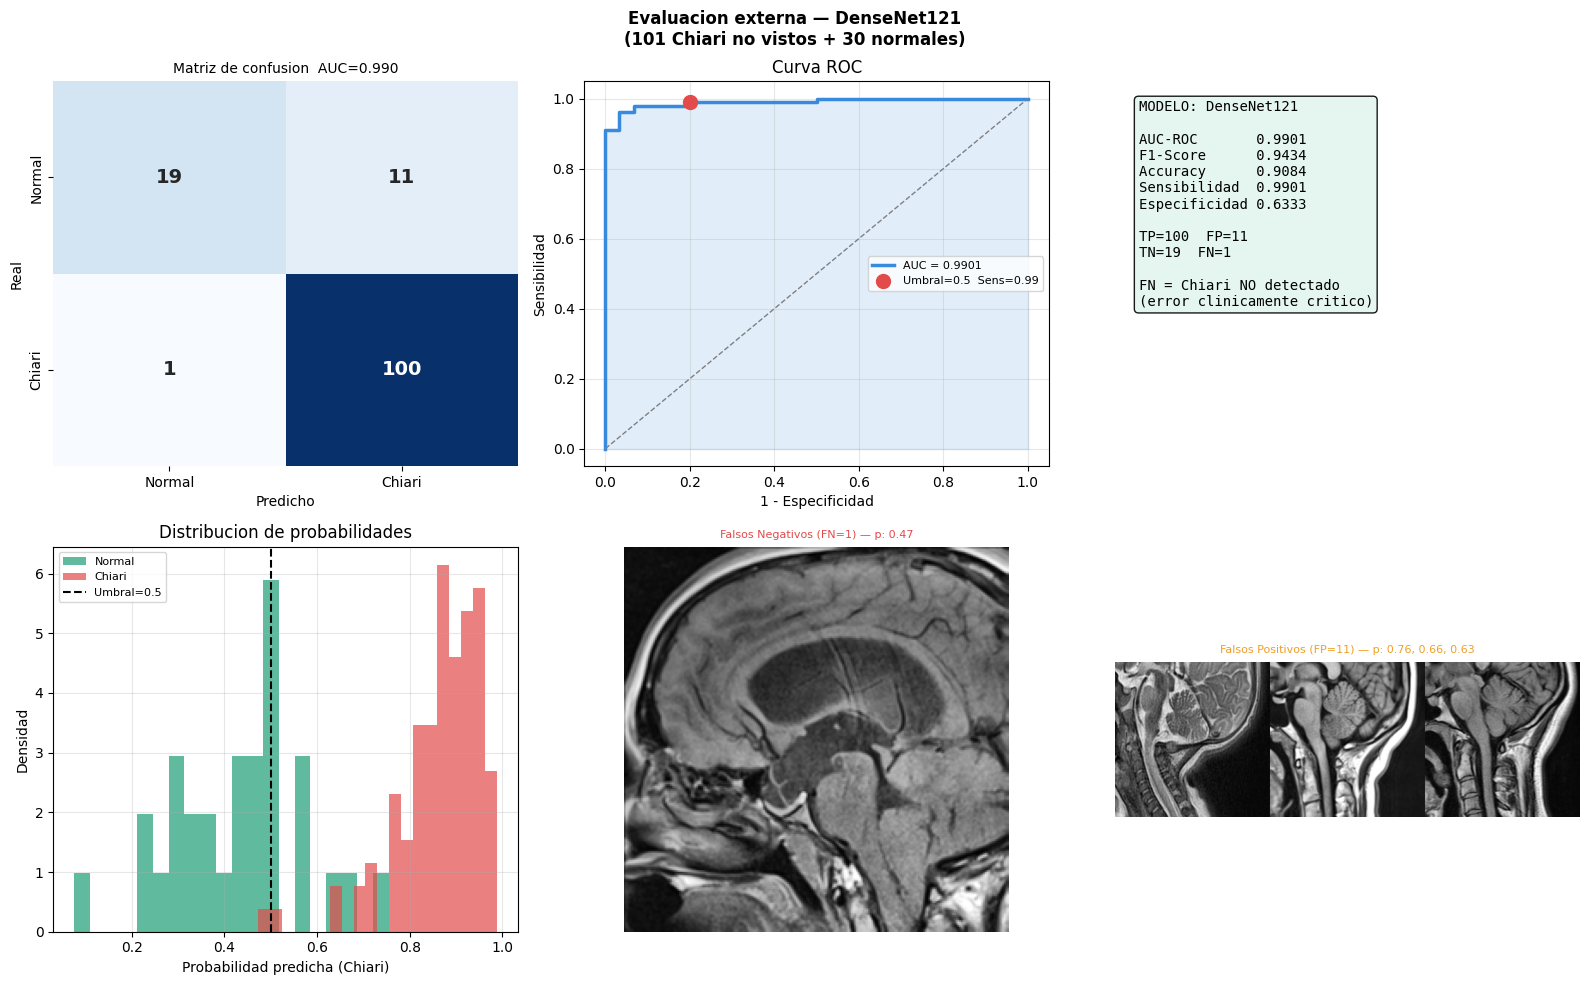

Guardado: reports/figures/evaluacion_externa.png


In [5]:
fig = plt.figure(figsize=(16, 10))
fig.suptitle(
    f'Evaluacion externa — {ARCH}\n'
    f'({metricas["n_chiari"]} Chiari no vistos + {metricas["n_normal"]} normales)',
    fontsize=12, fontweight='bold'
)
gs = gridspec.GridSpec(2, 3, figure=fig)

# Confusion matrix
ax1 = fig.add_subplot(gs[0, 0])
cm  = confusion_matrix(y_true_ext, y_pred_ext)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['Normal','Chiari'],
            yticklabels=['Normal','Chiari'], cbar=False,
            annot_kws={'size': 14, 'weight': 'bold'})
ax1.set_title(f'Matriz de confusion  AUC={metricas["auc"]:.3f}', fontsize=10)
ax1.set_ylabel('Real'); ax1.set_xlabel('Predicho')

# ROC curve
ax2 = fig.add_subplot(gs[0, 1])
fpr, tpr, umbrales = roc_curve(y_true_ext, y_prob_ext)
ax2.fill_between(fpr, tpr, alpha=0.15, color='#378ADD')
ax2.plot(fpr, tpr, '#378ADD', lw=2.5, label=f'AUC = {metricas["auc"]:.4f}')
ax2.plot([0,1],[0,1], '--', color='gray', lw=1)
idx05 = np.argmin(np.abs(umbrales - 0.5))
ax2.scatter(fpr[idx05], tpr[idx05], s=100, color='#E24B4A', zorder=5,
            label=f'Umbral=0.5  Sens={metricas["sensibilidad"]:.2f}')
ax2.set_xlabel('1 - Especificidad'); ax2.set_ylabel('Sensibilidad')
ax2.set_title('Curva ROC'); ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

# Resumen textual
ax3 = fig.add_subplot(gs[0, 2])
ax3.axis('off')
texto = (
    f'MODELO: {ARCH}\n\n'
    f'AUC-ROC       {metricas["auc"]:.4f}\n'
    f'F1-Score      {metricas["f1"]:.4f}\n'
    f'Accuracy      {metricas["accuracy"]:.4f}\n'
    f'Sensibilidad  {metricas["sensibilidad"]:.4f}\n'
    f'Especificidad {metricas["especificidad"]:.4f}\n\n'
    f'TP={metricas["tp"]}  FP={metricas["fp"]}\n'
    f'TN={metricas["tn"]}  FN={metricas["fn"]}\n\n'
    f'FN = Chiari NO detectado\n(error clinicamente critico)'
)
bg = '#E1F5EE' if metricas['auc'] >= 0.70 else '#FAEEDA'
ax3.text(0.05, 0.95, texto, transform=ax3.transAxes,
         fontsize=10, va='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor=bg, alpha=0.9))

# Histograma de probabilidades
ax4 = fig.add_subplot(gs[1, 0])
ax4.hist(y_prob_ext[y_true_ext==0], bins=20, alpha=0.7,
         color='#1D9E75', label='Normal', density=True)
ax4.hist(y_prob_ext[y_true_ext==1], bins=20, alpha=0.7,
         color='#E24B4A', label='Chiari', density=True)
ax4.axvline(0.5, color='black', linestyle='--', lw=1.5, label='Umbral=0.5')
ax4.set_xlabel('Probabilidad predicha (Chiari)')
ax4.set_ylabel('Densidad'); ax4.set_title('Distribucion de probabilidades')
ax4.legend(fontsize=8); ax4.grid(alpha=0.3)

# Falsos Negativos
ax5 = fig.add_subplot(gs[1, 1])
idx_fn = np.where((y_true_ext==1) & (y_pred_ext==0))[0]
if len(idx_fn):
    idx_fn_s = idx_fn[np.argsort(y_prob_ext[idx_fn])[::-1]]
    n_show = min(3, len(idx_fn_s))
    imgs = [cargar_imagen(rutas_ext[i])[:,:,0] for i in idx_fn_s[:n_show]]
    ax5.imshow(np.concatenate(imgs, axis=1), cmap='gray')
    ax5.set_title(
        f'Falsos Negativos (FN={len(idx_fn)}) — p: '
        + ', '.join([f'{y_prob_ext[i]:.2f}' for i in idx_fn_s[:n_show]]),
        fontsize=8, color='#E24B4A')
else:
    ax5.text(0.5, 0.5, 'Sin FN', ha='center', va='center',
             fontsize=12, color='#1D9E75', fontweight='bold',
             transform=ax5.transAxes)
ax5.axis('off')

# Falsos Positivos
ax6 = fig.add_subplot(gs[1, 2])
idx_fp = np.where((y_true_ext==0) & (y_pred_ext==1))[0]
if len(idx_fp):
    idx_fp_s = idx_fp[np.argsort(y_prob_ext[idx_fp])[::-1]]
    n_show = min(3, len(idx_fp_s))
    imgs = [cargar_imagen(rutas_ext[i])[:,:,0] for i in idx_fp_s[:n_show]]
    ax6.imshow(np.concatenate(imgs, axis=1), cmap='gray')
    ax6.set_title(
        f'Falsos Positivos (FP={len(idx_fp)}) — p: '
        + ', '.join([f'{y_prob_ext[i]:.2f}' for i in idx_fp_s[:n_show]]),
        fontsize=8, color='#EF9F27')
else:
    ax6.text(0.5, 0.5, 'Sin FP', ha='center', va='center',
             fontsize=12, color='#1D9E75', fontweight='bold',
             transform=ax6.transAxes)
ax6.axis('off')

plt.tight_layout()
plt.savefig(str(DIR_FIGURES / 'evaluacion_externa.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: reports/figures/evaluacion_externa.png')

### A5. Grad-CAM en casos externos

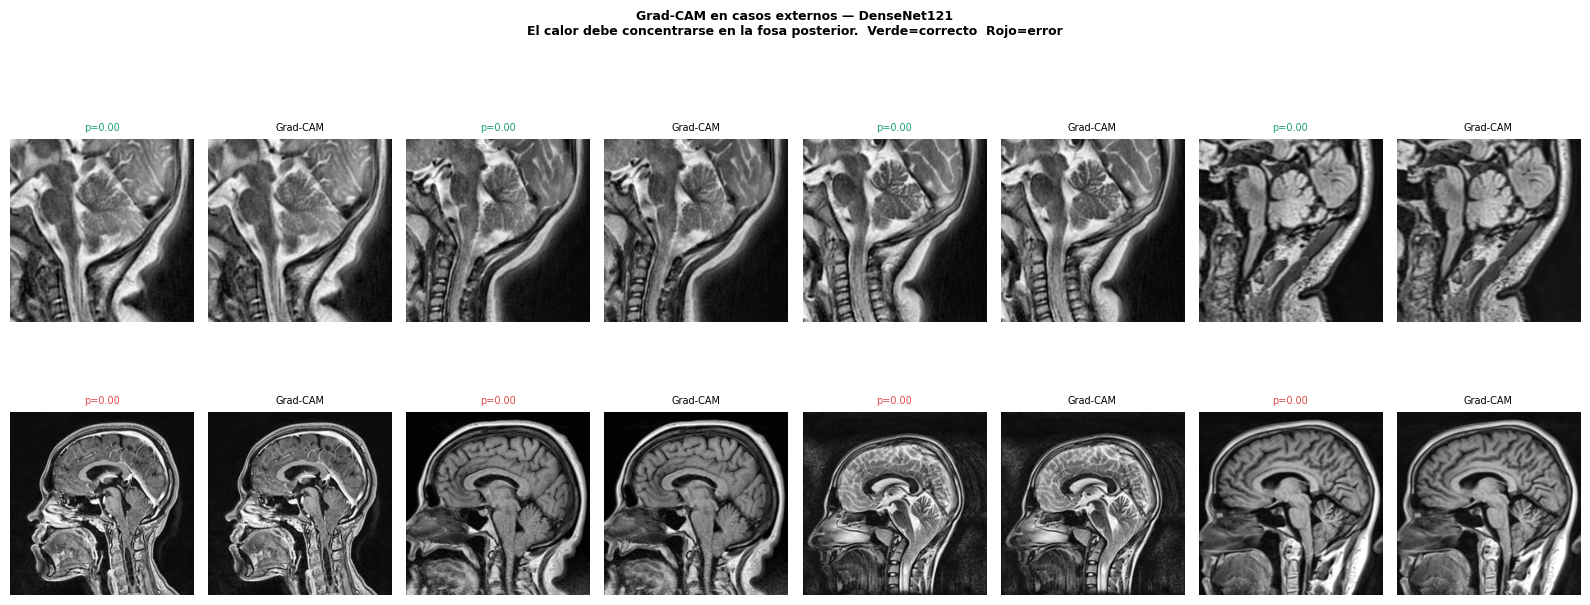

Guardado: reports/gradcam/gradcam_externo.png


In [6]:
LAST_CONV = {
    'DenseNet121'   : 'conv5_block16_concat',
    'EfficientNetB0': 'top_conv',
    'ResNet50V2'    : 'post_relu',
}

def make_gradcam(modelo, img_array, last_conv):
    gm = keras.Model(inputs=modelo.inputs,
                     outputs=[modelo.get_layer(last_conv).output, modelo.output])
    with tf.GradientTape() as tape:
        co, preds = gm(img_array)
        loss = preds[:, 0]
    grads   = tape.gradient(loss, co)
    pooled  = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = tf.squeeze(co[0] @ pooled[..., tf.newaxis]).numpy()
    heatmap = np.maximum(heatmap, 0)
    if heatmap.max() > 0:
        heatmap /= heatmap.max()
    return heatmap, float(preds[0, 0])

last_conv  = LAST_CONV.get(ARCH, 'conv5_block16_concat')
n_muestras = 4

fig, axes = plt.subplots(2, n_muestras*2, figsize=(n_muestras*4, 7))
fig.suptitle(
    f'Grad-CAM en casos externos — {ARCH}\n'
    'El calor debe concentrarse en la fosa posterior.  '
    'Verde=correcto  Rojo=error',
    fontsize=9, fontweight='bold'
)

for row_idx, (clase_id, clase_str, color) in enumerate([
    (0, 'Normal', '#1D9E75'), (1, 'Chiari', '#E24B4A')
]):
    rutas_clase = [rutas_ext[i] for i, l in enumerate(labels_ext)
                   if l == clase_id][:n_muestras]
    for ci, ruta in enumerate(rutas_clase):
        img    = cargar_imagen(ruta)
        img_in = np.expand_dims(img, 0)
        try:
            hm, prob = make_gradcam(modelo, img_in, last_conv)
            hm_r     = cv2.resize(hm, (img.shape[1], img.shape[0]))
            hm_c     = cv2.cvtColor(
                cv2.applyColorMap(np.uint8(255*hm_r), cv2.COLORMAP_JET),
                cv2.COLOR_BGR2RGB
            )
            overlay = cv2.addWeighted(np.uint8(img*255), 0.6, hm_c, 0.4, 0)
        except Exception:
            overlay, prob = np.uint8(img*255), 0.0

        pred = 'Chiari' if prob >= 0.5 else 'Normal'
        tc   = '#1D9E75' if pred == clase_str else '#E24B4A'
        axes[row_idx][ci*2].imshow(img[:,:,0], cmap='gray')
        axes[row_idx][ci*2].set_title(f'p={prob:.2f}', fontsize=7, color=tc)
        axes[row_idx][ci*2].axis('off')
        axes[row_idx][ci*2+1].imshow(overlay)
        axes[row_idx][ci*2+1].set_title('Grad-CAM', fontsize=7)
        axes[row_idx][ci*2+1].axis('off')
    axes[row_idx][0].set_ylabel(clase_str, fontsize=9, fontweight='bold', color=color)

plt.tight_layout()
plt.savefig(str(DIR_GRADCAM / 'gradcam_externo.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: reports/gradcam/gradcam_externo.png')

### A6. Reporte final

In [7]:
ruta_json = DIR_REPORTS / 'resultados_kfold.json'
kfold_data = {}
if ruta_json.exists():
    with open(ruta_json) as f:
        kfold_data = json.load(f)

reporte_final = {
    'fecha'             : datetime.now().isoformat(),
    'modelo'            : ruta_modelo.name,
    'arquitectura'      : ARCH,
    'evaluacion_externa': metricas,
    'kfold_metricas'    : kfold_data.get('metricas_kfold', {}),
}
with open(DIR_REPORTS / 'reporte_final.json', 'w', encoding='utf-8') as f:
    json.dump(reporte_final, f, indent=2, ensure_ascii=False)

print('=' * 55)
print('  PARTE A COMPLETADA')
print('=' * 55)
print(f'  Modelo        : {ARCH}')
print(f'  AUC externo   : {metricas["auc"]:.4f}')
print(f'  Sensibilidad  : {metricas["sensibilidad"]:.4f}')
print(f'  Especificidad : {metricas["especificidad"]:.4f}')
print(f'  FN            : {metricas["fn"]}')
print()
print('  Archivos generados:')
print('    reports/figures/evaluacion_externa.png')
print('    reports/gradcam/gradcam_externo.png')
print('    reports/reporte_final.json')
print('=' * 55)

  PARTE A COMPLETADA
  Modelo        : DenseNet121
  AUC externo   : 0.9901
  Sensibilidad  : 0.9901
  Especificidad : 0.6333
  FN            : 1

  Archivos generados:
    reports/figures/evaluacion_externa.png
    reports/gradcam/gradcam_externo.png
    reports/reporte_final.json
